# 22. Multi-Horizon and Regime-Specific Modeling

## Objective
Improve predictive signal quality by moving from **single-step (t+1)** to **multi-horizon (t+3, t+5)** forecasting, and compare **global** versus **regime-specific** models.

This notebook enforces:
- strict time-series split (no shuffling)
- leakage-safe target construction via forward shift per ticker
- train-only scaling
- consistent evaluation metrics across horizons and regimes

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Optional, Tuple
import json
import logging

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from xgboost import XGBClassifier

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 240)
pd.set_option('display.width', 220)

RANDOM_STATE = 42
TRAIN_START = pd.Timestamp('2023-04-18')
TRAIN_END = pd.Timestamp('2024-12-31')
TEST_START = pd.Timestamp('2025-01-01')
TEST_END = pd.Timestamp('2025-12-30')

HORIZONS = [1, 3, 5]
REGIMES = ['LOW', 'MEDIUM', 'HIGH']

SEQUENCE_WINDOW = 20
BATCH_SIZE = 64
TRANSFORMER_EPOCHS = 8
EARLY_STOPPING_PATIENCE = 3
LEARNING_RATE = 1e-3
VAL_FRACTION = 0.15

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

logger = logging.getLogger('multi_horizon_regime')
if not logger.handlers:
    handler = logging.StreamHandler()
    handler.setFormatter(logging.Formatter('[%(levelname)s] %(message)s'))
    logger.addHandler(handler)
logger.setLevel(logging.INFO)

print(f'Using device: {DEVICE}')

Using device: cpu


## STEP 1: Load Data

In [2]:
def resolve_project_root() -> Path:
    cwd = Path.cwd()
    for c in [cwd, cwd.parent, cwd.parent.parent]:
        if (c / 'ml_pipeline').exists() and (c / 'CLAUDE.md').exists():
            return c
    raise FileNotFoundError('Unable to locate project root.')


ROOT = resolve_project_root()
DATA_PATH = ROOT / 'ml_pipeline' / 'Market_Data' / 'processed' / 'final_model_dataset.parquet'
MODELS_DIR = ROOT / 'ml_pipeline' / 'models' / 'multi_horizon_regime'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

assert DATA_PATH.exists(), f'Missing dataset: {DATA_PATH}'

df = pd.read_parquet(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'], errors='raise')
df['Ticker'] = df['Ticker'].astype(str)
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

assert {'Ticker', 'Date', 'Close'}.issubset(df.columns), 'Required columns missing.'
logger.info('Loaded dataset shape: %s', f'{df.shape[0]:,} x {df.shape[1]}')
display(df[['Ticker', 'Date', 'Close']].head())

[INFO] Loaded dataset shape: 63,541 x 156


,Ticker,Date,Close
0,ABB,2023-04-18,3207.699951
1,ABB,2023-04-19,3201.050049
2,ABB,2023-04-20,3184.300049
3,ABB,2023-04-21,3153.300049
4,ABB,2023-04-24,3217.399902


## STEP 2: Create Multi-Horizon Targets (Leakage-Safe)

In [3]:
def create_multi_horizon_targets(data: pd.DataFrame, horizons: List[int]) -> pd.DataFrame:
    out = data.copy()
    g = out.groupby('Ticker', sort=False)['Close']

    if 'target' in out.columns:
        out['target_t1'] = out['target'].astype(float)
    else:
        close_t1 = g.shift(-1)
        out['target_t1'] = (close_t1 > out['Close']).astype(float)
        out.loc[close_t1.isna(), 'target_t1'] = np.nan

    for h in horizons:
        if h == 1:
            continue
        future_close = g.shift(-h)
        col = f'target_t{h}'
        out[col] = (future_close > out['Close']).astype(float)
        out.loc[future_close.isna(), col] = np.nan

    return out


def add_or_infer_regime_label(data: pd.DataFrame, train_mask: pd.Series) -> pd.DataFrame:
    out = data.copy()
    existing_cols = [c for c in out.columns if c.lower() in {'volatility_regime_label', 'regime'}]
    if existing_cols:
        out['volatility_regime_label'] = out[existing_cols[0]].astype(str).str.upper()
        return out

    assert 'Volatility_20' in out.columns, 'volatility_regime_label missing and Volatility_20 unavailable for inference.'

    q1 = float(out.loc[train_mask, 'Volatility_20'].quantile(1 / 3))
    q2 = float(out.loc[train_mask, 'Volatility_20'].quantile(2 / 3))

    def _to_regime(v: float) -> str:
        if v <= q1:
            return 'LOW'
        if v <= q2:
            return 'MEDIUM'
        return 'HIGH'

    out['volatility_regime_label'] = out['Volatility_20'].map(_to_regime)
    return out


base_train_mask = (df['Date'] >= TRAIN_START) & (df['Date'] <= TRAIN_END)
df = create_multi_horizon_targets(df, HORIZONS)
df = add_or_infer_regime_label(df, train_mask=base_train_mask)

for c in ['target_t1', 'target_t3', 'target_t5']:
    assert c in df.columns, f'Missing target column: {c}'

assert df['volatility_regime_label'].isin(REGIMES).all(), 'Unexpected regime labels found.'
display(df[['Ticker', 'Date', 'Close', 'target_t1', 'target_t3', 'target_t5', 'volatility_regime_label']].head(12))

,Ticker,Date,Close,target_t1,target_t3,target_t5,volatility_regime_label
0,ABB,2023-04-18,3207.699951,0.0,0.0,1.0,MEDIUM
1,ABB,2023-04-19,3201.050049,0.0,1.0,1.0,MEDIUM
2,ABB,2023-04-20,3184.300049,0.0,1.0,1.0,MEDIUM
3,ABB,2023-04-21,3153.300049,1.0,1.0,1.0,MEDIUM
4,ABB,2023-04-24,3217.399902,1.0,1.0,1.0,MEDIUM
5,ABB,2023-04-25,3336.100098,1.0,1.0,1.0,MEDIUM
6,ABB,2023-04-26,3400.149902,1.0,1.0,1.0,MEDIUM
7,ABB,2023-04-27,3411.600098,1.0,1.0,1.0,MEDIUM
8,ABB,2023-04-28,3417.949951,1.0,1.0,1.0,MEDIUM
9,ABB,2023-05-02,3442.149902,1.0,1.0,1.0,MEDIUM


## STEP 3/4: Train Global and Regime-Specific Models

Models:
- XGBoost (tabular baseline)
- Transformer (sequence model)

Training scopes:
- Global (all regimes)
- Regime-specific (LOW / MEDIUM / HIGH)

In [4]:
TARGET_COLUMNS = ['target_t1', 'target_t3', 'target_t5']
DROP_EXACT = {'Date', 'Ticker', 'target', 'target_t1', 'target_t3', 'target_t5', 'volatility_regime_label'}
feature_cols = [c for c in df.columns if c not in DROP_EXACT]

assert len(feature_cols) > 0, 'No features selected.'
non_numeric_cols = df[feature_cols].select_dtypes(exclude=[np.number]).columns.tolist()
assert not non_numeric_cols, f'Non-numeric features present: {non_numeric_cols[:10]}'
assert df[feature_cols].isna().sum().sum() == 0, 'NaN values in selected features.'

print(f'Feature count: {len(feature_cols)}')

Feature count: 153


In [5]:
def safe_roc_auc(y_true: np.ndarray, y_prob: np.ndarray) -> float:
    if len(np.unique(y_true)) < 2:
        return float('nan')
    return float(roc_auc_score(y_true, y_prob))


def compute_metrics(y_true: np.ndarray, y_prob: np.ndarray) -> Dict[str, float]:
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        'Accuracy': float(accuracy_score(y_true, y_pred)),
        'Precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'Recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'F1': float(f1_score(y_true, y_pred, zero_division=0)),
        'ROC_AUC': safe_roc_auc(y_true, y_prob),
    }


class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int) -> None:
        super().__init__()
        self.pe = nn.Parameter(torch.zeros(1, max_len, d_model))
        nn.init.normal_(self.pe, mean=0.0, std=0.02)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pe[:, :x.size(1), :]


class TransformerClassifier(nn.Module):
    def __init__(
        self,
        input_size: int,
        d_model: int = 64,
        n_heads: int = 4,
        num_layers: int = 2,
        dropout: float = 0.2,
        max_len: int = 20,
    ) -> None:
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_enc = PositionalEncoding(d_model=d_model, max_len=max_len)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dropout=dropout,
            batch_first=True,
            dim_feedforward=d_model * 4,
            activation='gelu',
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(d_model, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.input_proj(x)
        h = self.pos_enc(h)
        h = self.encoder(h)
        pooled = h.mean(dim=1)
        return self.head(self.dropout(pooled)).squeeze(-1)


def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: Optional[torch.optim.Optimizer],
) -> Tuple[float, np.ndarray, np.ndarray]:
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    all_true: List[np.ndarray] = []
    all_prob: List[np.ndarray] = []

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        logits = model(xb)
        loss = criterion(logits, yb)

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_loss += float(loss.item()) * xb.size(0)
        all_true.append(yb.detach().cpu().numpy())
        all_prob.append(torch.sigmoid(logits).detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    y_true = np.concatenate(all_true)
    y_prob = np.concatenate(all_prob)
    return avg_loss, y_true, y_prob


def train_transformer(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int = TRANSFORMER_EPOCHS,
    patience: int = EARLY_STOPPING_PATIENCE,
    lr: float = LEARNING_RATE,
) -> nn.Module:
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_state = None
    best_val_loss = float('inf')
    patience_count = 0

    for ep in range(1, epochs + 1):
        tr_loss, _, _ = run_epoch(model, train_loader, criterion, optimizer)
        va_loss, _, _ = run_epoch(model, val_loader, criterion, None)

        if va_loss < best_val_loss:
            best_val_loss = va_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                break

    assert best_state is not None, 'Transformer training failed to produce a checkpoint.'
    model.load_state_dict(best_state)
    return model


def make_sequences(
    data_sorted: pd.DataFrame,
    scaled_features: pd.DataFrame,
    features: List[str],
    target_col: str,
    window: int,
) -> Tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    seq_x: List[np.ndarray] = []
    seq_y: List[float] = []
    meta: List[Dict[str, object]] = []

    temp = data_sorted[['Ticker', 'Date', 'volatility_regime_label', target_col]].copy()
    temp[features] = scaled_features[features].values

    for ticker, grp in temp.groupby('Ticker', sort=False):
        vals = grp[features].to_numpy(dtype=np.float32)
        tgt = grp[target_col].to_numpy(dtype=np.float32)
        dts = grp['Date'].to_numpy()
        reg = grp['volatility_regime_label'].astype(str).to_numpy()

        if len(grp) < window:
            continue

        for i in range(window - 1, len(grp)):
            if np.isnan(tgt[i]):
                continue
            seq_x.append(vals[i - window + 1 : i + 1])
            seq_y.append(tgt[i])
            meta.append({'Ticker': ticker, 'Date': pd.Timestamp(dts[i]), 'Regime': reg[i]})

    return np.asarray(seq_x, dtype=np.float32), np.asarray(seq_y, dtype=np.float32), pd.DataFrame(meta)


def split_train_test_masks(meta_df: pd.DataFrame) -> Tuple[pd.Series, pd.Series]:
    tr = (meta_df['Date'] >= TRAIN_START) & (meta_df['Date'] <= TRAIN_END)
    te = (meta_df['Date'] >= TEST_START) & (meta_df['Date'] <= TEST_END)
    return tr, te


def split_train_val_sequence(meta_train: pd.DataFrame, val_fraction: float = VAL_FRACTION) -> Tuple[pd.Series, pd.Series]:
    unique_dates = np.array(sorted(meta_train['Date'].unique()))
    assert len(unique_dates) > 2, 'Not enough unique dates for sequence train/validation split.'

    cut_idx = int(len(unique_dates) * (1 - val_fraction))
    cut_idx = min(max(cut_idx, 1), len(unique_dates) - 1)
    cut_date = pd.Timestamp(unique_dates[cut_idx])

    fit_mask = meta_train['Date'] < cut_date
    val_mask = meta_train['Date'] >= cut_date
    assert fit_mask.any() and val_mask.any(), 'Empty fit/validation subset in sequence split.'
    return fit_mask, val_mask

In [6]:
def train_xgb_and_eval(
    data: pd.DataFrame,
    target_col: str,
    features: List[str],
    regime_filter: Optional[str] = None,
) -> Tuple[Dict[str, float], pd.DataFrame, Dict[str, object]]:
    work = data[['Date', 'Ticker', 'volatility_regime_label', target_col] + features].copy()
    work = work.dropna(subset=[target_col]).reset_index(drop=True)

    tr_mask = (work['Date'] >= TRAIN_START) & (work['Date'] <= TRAIN_END)
    te_mask = (work['Date'] >= TEST_START) & (work['Date'] <= TEST_END)

    if regime_filter is not None:
        tr_mask = tr_mask & (work['volatility_regime_label'] == regime_filter)
        te_mask = te_mask & (work['volatility_regime_label'] == regime_filter)

    train_df = work.loc[tr_mask].copy()
    test_df = work.loc[te_mask].copy()
    if len(train_df) < 500 or len(test_df) < 100:
        raise ValueError(f'Insufficient data for XGB ({regime_filter}, {target_col}). train={len(train_df)}, test={len(test_df)}')

    xgb = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    xgb.fit(train_df[features], train_df[target_col].astype(int))

    y_true = test_df[target_col].astype(int).to_numpy()
    y_prob = xgb.predict_proba(test_df[features])[:, 1]
    m = compute_metrics(y_true, y_prob)

    pred_df = test_df[['Date', 'Ticker', 'volatility_regime_label']].copy()
    pred_df['y_true'] = y_true
    pred_df['y_prob'] = y_prob
    pred_df['y_pred'] = (y_prob >= 0.5).astype(int)

    obj = {'model': xgb, 'feature_cols': features, 'target_col': target_col}
    return m, pred_df, obj


def train_transformer_and_eval(
    data: pd.DataFrame,
    target_col: str,
    features: List[str],
    regime_filter: Optional[str] = None,
) -> Tuple[Dict[str, float], pd.DataFrame, Dict[str, object]]:
    work = data[['Ticker', 'Date', 'volatility_regime_label', target_col] + features].copy()
    work = work.dropna(subset=[target_col]).sort_values(['Ticker', 'Date']).reset_index(drop=True)

    train_rows = (work['Date'] >= TRAIN_START) & (work['Date'] <= TRAIN_END)
    scaler = StandardScaler()
    scaled = pd.DataFrame(
        scaler.fit_transform(work.loc[train_rows, features]).astype(np.float32),
        columns=features,
        index=work.loc[train_rows].index,
    )
    scaled_full = pd.DataFrame(index=work.index, columns=features, dtype=np.float32)
    scaled_full.loc[scaled.index, features] = scaled.values
    scaled_full.loc[~train_rows, features] = scaler.transform(work.loc[~train_rows, features]).astype(np.float32)
    scaled_full = scaled_full.sort_index()

    X_seq, y_seq, meta = make_sequences(work, scaled_full, features, target_col, window=SEQUENCE_WINDOW)
    if len(meta) == 0:
        raise ValueError(f'No sequences generated for {target_col}, regime={regime_filter}')

    tr_mask, te_mask = split_train_test_masks(meta)
    if regime_filter is not None:
        tr_mask = tr_mask & (meta['Regime'] == regime_filter)
        te_mask = te_mask & (meta['Regime'] == regime_filter)

    X_train = X_seq[tr_mask.values]
    y_train = y_seq[tr_mask.values]
    X_test = X_seq[te_mask.values]
    y_test = y_seq[te_mask.values]
    meta_train = meta.loc[tr_mask].reset_index(drop=True)
    meta_test = meta.loc[te_mask].reset_index(drop=True)

    if len(X_train) < 1000 or len(X_test) < 200:
        raise ValueError(f'Insufficient sequence data ({regime_filter}, {target_col}). train={len(X_train)}, test={len(X_test)}')

    fit_mask, val_mask = split_train_val_sequence(meta_train, val_fraction=VAL_FRACTION)
    X_fit, y_fit = X_train[fit_mask.values], y_train[fit_mask.values]
    X_val, y_val = X_train[val_mask.values], y_train[val_mask.values]

    fit_ds = TensorDataset(torch.from_numpy(X_fit), torch.from_numpy(y_fit))
    val_ds = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))
    test_ds = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))

    fit_loader = DataLoader(fit_ds, batch_size=BATCH_SIZE, shuffle=False)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    model = TransformerClassifier(input_size=len(features), max_len=SEQUENCE_WINDOW).to(DEVICE)
    model = train_transformer(model, fit_loader, val_loader)

    model.eval()
    all_prob: List[np.ndarray] = []
    with torch.no_grad():
        for xb, _ in test_loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_prob.append(probs)

    y_prob = np.concatenate(all_prob)
    m = compute_metrics(y_test.astype(int), y_prob)

    pred_df = meta_test[['Date', 'Ticker', 'Regime']].copy()
    pred_df = pred_df.rename(columns={'Regime': 'volatility_regime_label'})
    pred_df['y_true'] = y_test.astype(int)
    pred_df['y_prob'] = y_prob
    pred_df['y_pred'] = (y_prob >= 0.5).astype(int)

    obj = {
        'model': model,
        'scaler': scaler,
        'feature_cols': features,
        'target_col': target_col,
        'sequence_window': SEQUENCE_WINDOW,
    }
    return m, pred_df, obj

In [7]:
results_records: List[Dict[str, object]] = []
pred_store: List[pd.DataFrame] = []
trained_objects: Dict[Tuple[str, str, str, int], Dict[str, object]] = {}

def register_result(
    scope: str,
    regime: str,
    model_name: str,
    horizon: int,
    metrics: Dict[str, float],
    pred_df: pd.DataFrame,
    model_obj: Dict[str, object],
) -> None:
    rec = {'Scope': scope, 'Regime': regime, 'Model': model_name, 'Horizon': f't+{horizon}', **metrics}
    results_records.append(rec)

    p = pred_df.copy()
    p['Scope'] = scope
    p['RegimeScope'] = regime
    p['Model'] = model_name
    p['Horizon'] = f't+{horizon}'
    pred_store.append(p)

    trained_objects[(scope, regime, model_name, horizon)] = model_obj


for h in HORIZONS:
    target_col = f'target_t{h}'
    for model_name in ['XGBoost', 'Transformer']:
        try:
            if model_name == 'XGBoost':
                m, p, obj = train_xgb_and_eval(df, target_col, feature_cols, regime_filter=None)
            else:
                m, p, obj = train_transformer_and_eval(df, target_col, feature_cols, regime_filter=None)
            register_result('global', 'ALL', model_name, h, m, p, obj)
            logger.info('Finished global %s for %s', model_name, target_col)
        except Exception as ex:
            logger.warning('Skipped global %s %s due to: %s', model_name, target_col, ex)

for regime in REGIMES:
    for h in HORIZONS:
        target_col = f'target_t{h}'
        for model_name in ['XGBoost', 'Transformer']:
            try:
                if model_name == 'XGBoost':
                    m, p, obj = train_xgb_and_eval(df, target_col, feature_cols, regime_filter=regime)
                else:
                    m, p, obj = train_transformer_and_eval(df, target_col, feature_cols, regime_filter=regime)
                register_result('regime-specific', regime, model_name, h, m, p, obj)
                logger.info('Finished %s %s for %s', regime, model_name, target_col)
            except Exception as ex:
                logger.warning('Skipped %s %s %s due to: %s', regime, model_name, target_col, ex)

results_df = pd.DataFrame(results_records)
predictions_df = pd.concat(pred_store, ignore_index=True) if pred_store else pd.DataFrame()

assert len(results_df) > 0, 'No model results were produced.'
display(results_df.sort_values(['Scope', 'Regime', 'Model', 'Horizon']).reset_index(drop=True).round(4).head(30))

[INFO] Finished global XGBoost for target_t1
C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_10164\912271817.py:141: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  temp[features] = scaled_features[features].values
C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_10164\912271817.py:141: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  temp[features] = scaled_features[features].values
C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_10164\912271817.py:141: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result o

,Scope,Regime,Model,Horizon,Accuracy,Precision,Recall,F1,ROC_AUC
0,global,ALL,Transformer,t+1,0.5010,0.4891,0.0603,0.1074,0.5148
1,global,ALL,Transformer,t+3,0.5044,0.5094,0.2597,0.3440,0.5064
2,global,ALL,Transformer,t+5,0.4862,0.5092,0.0802,0.1386,0.4968
3,global,ALL,XGBoost,t+1,0.5018,0.4995,0.4852,0.4923,0.5068
4,global,ALL,XGBoost,t+3,0.4964,0.4967,0.4682,0.4820,0.4954
5,global,ALL,XGBoost,t+5,0.5032,0.5164,0.5657,0.5400,0.5004
6,regime-specific,HIGH,Transformer,t+1,0.5188,0.5206,0.7009,0.5975,0.5221
7,regime-specific,HIGH,Transformer,t+3,0.5378,0.5545,0.5776,0.5658,0.5485
8,regime-specific,HIGH,Transformer,t+5,0.5290,0.5537,0.6264,0.5878,0.5349
9,regime-specific,HIGH,XGBoost,t+1,0.5178,0.5308,0.4609,0.4934,0.5218


## STEP 5: Evaluation Comparisons

Compare:
- t+1 vs t+3 vs t+5
- global vs regime-specific

In [8]:
global_cmp = results_df[results_df['Scope'] == 'global'].copy()
regime_cmp = results_df[results_df['Scope'] == 'regime-specific'].copy()

print('Global comparison (horizons x models):')
display(global_cmp.sort_values(['Model', 'Horizon']).reset_index(drop=True).round(4))

print('Regime-specific comparison:')
display(regime_cmp.sort_values(['Regime', 'Model', 'Horizon']).reset_index(drop=True).round(4))

pivot_f1 = results_df.pivot_table(
    index=['Scope', 'Regime', 'Model'],
    columns='Horizon',
    values='F1',
    aggfunc='mean',
)
print('F1 pivot (scope/regime/model by horizon):')
display(pivot_f1.round(4))

Global comparison (horizons x models):


,Scope,Regime,Model,Horizon,Accuracy,Precision,Recall,F1,ROC_AUC
0,global,ALL,Transformer,t+1,0.5010,0.4891,0.0603,0.1074,0.5148
1,global,ALL,Transformer,t+3,0.5044,0.5094,0.2597,0.3440,0.5064
2,global,ALL,Transformer,t+5,0.4862,0.5092,0.0802,0.1386,0.4968
3,global,ALL,XGBoost,t+1,0.5018,0.4995,0.4852,0.4923,0.5068
4,global,ALL,XGBoost,t+3,0.4964,0.4967,0.4682,0.4820,0.4954
5,global,ALL,XGBoost,t+5,0.5032,0.5164,0.5657,0.5400,0.5004


Regime-specific comparison:


,Scope,Regime,Model,Horizon,Accuracy,Precision,Recall,F1,ROC_AUC
0,regime-specific,HIGH,Transformer,t+1,0.5188,0.5206,0.7009,0.5975,0.5221
1,regime-specific,HIGH,Transformer,t+3,0.5378,0.5545,0.5776,0.5658,0.5485
2,regime-specific,HIGH,Transformer,t+5,0.5290,0.5537,0.6264,0.5878,0.5349
3,regime-specific,HIGH,XGBoost,t+1,0.5178,0.5308,0.4609,0.4934,0.5218
4,regime-specific,HIGH,XGBoost,t+3,0.5233,0.5536,0.4418,0.4914,0.5349
5,regime-specific,HIGH,XGBoost,t+5,0.5083,0.5532,0.4319,0.4851,0.5154
6,regime-specific,LOW,Transformer,t+1,0.5039,0.4815,0.0939,0.1572,0.5060
7,regime-specific,LOW,Transformer,t+3,0.5061,0.4570,0.0297,0.0558,0.4986
8,regime-specific,LOW,Transformer,t+5,0.4918,0.4663,0.0335,0.0624,0.5065
9,regime-specific,LOW,XGBoost,t+1,0.4967,0.4902,0.5438,0.5156,0.5054


F1 pivot (scope/regime/model by horizon):


Horizon                                t+1     t+3     t+5
Scope           Regime Model                              
global          ALL    Transformer  0.1074  0.3440  0.1386
                       XGBoost      0.4923  0.4820  0.5400
regime-specific HIGH   Transformer  0.5975  0.5658  0.5878
                       XGBoost      0.4934  0.4914  0.4851
                LOW    Transformer  0.1572  0.0558  0.0624
                       XGBoost      0.5156  0.5129  0.5320
                MEDIUM Transformer  0.1209  0.3362  0.4565
                       XGBoost      0.4597  0.4743  0.4711

## STEP 6: Signal Strength Analysis

We use probability spread diagnostics to check whether predictions move away from 0.5.

,Scope,RegimeScope,Model,Horizon,mean_prob,std_prob,mean_abs_distance,p10,p50,p90,n
0,global,ALL,Transformer,t+1,0.4645,0.0219,0.0366,0.4387,0.4615,0.4951,23808
1,global,ALL,Transformer,t+3,0.4724,0.0414,0.0368,0.4214,0.4778,0.5193,23520
2,global,ALL,Transformer,t+5,0.4652,0.0339,0.0447,0.4371,0.4602,0.4875,23328
3,global,ALL,XGBoost,t+1,0.4922,0.1178,0.0928,0.3397,0.4953,0.6376,23808
4,global,ALL,XGBoost,t+3,0.4848,0.1349,0.1092,0.3073,0.4899,0.6553,23520
5,global,ALL,XGBoost,t+5,0.5158,0.1486,0.1232,0.3127,0.5273,0.7018,23328
6,regime-specific,HIGH,Transformer,t+1,0.5106,0.0318,0.0269,0.4689,0.5145,0.5473,6819
7,regime-specific,HIGH,Transformer,t+3,0.5014,0.0489,0.0385,0.4369,0.5049,0.5583,6794
8,regime-specific,HIGH,Transformer,t+5,0.5127,0.0727,0.0579,0.4119,0.5195,0.5970,6779
9,regime-specific,HIGH,XGBoost,t+1,0.4822,0.1294,0.1049,0.3145,0.4804,0.6500,6819


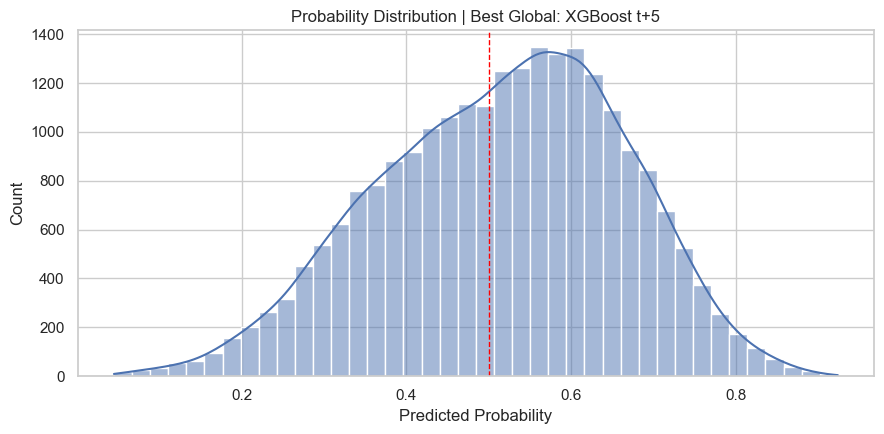

In [9]:
assert len(predictions_df) > 0, 'No prediction probabilities available for signal analysis.'

sig = predictions_df.copy()
sig['abs_distance_from_0_5'] = (sig['y_prob'] - 0.5).abs()

signal_summary = (
    sig.groupby(['Scope', 'RegimeScope', 'Model', 'Horizon'], as_index=False)
    .agg(
        mean_prob=('y_prob', 'mean'),
        std_prob=('y_prob', 'std'),
        mean_abs_distance=('abs_distance_from_0_5', 'mean'),
        p10=('y_prob', lambda x: np.quantile(x, 0.10)),
        p50=('y_prob', lambda x: np.quantile(x, 0.50)),
        p90=('y_prob', lambda x: np.quantile(x, 0.90)),
        n=('y_prob', 'size'),
    )
)
display(signal_summary.sort_values(['Scope', 'RegimeScope', 'Model', 'Horizon']).round(4).head(40))

best_global = (
    results_df[results_df['Scope'] == 'global']
    .sort_values(['F1', 'ROC_AUC'], ascending=False)
    .head(1)
)
if len(best_global) > 0:
    bg = best_global.iloc[0]
    m = (sig['Scope'] == 'global') & (sig['Model'] == bg['Model']) & (sig['Horizon'] == bg['Horizon'])
    plt.figure(figsize=(9, 4.5))
    sns.histplot(sig.loc[m, 'y_prob'], bins=40, kde=True)
    plt.axvline(0.5, color='red', linestyle='--', linewidth=1)
    plt.title(f"Probability Distribution | Best Global: {bg['Model']} {bg['Horizon']}")
    plt.xlabel('Predicted Probability')
    plt.tight_layout()
    plt.show()

## STEP 7: Save Best-Performing Model per Regime

In [10]:
regime_results = results_df[results_df['Scope'] == 'regime-specific'].copy()
best_per_regime = (
    regime_results.sort_values(['Regime', 'F1', 'ROC_AUC'], ascending=[True, False, False])
    .groupby('Regime', as_index=False)
    .head(1)
    .reset_index(drop=True)
)

saved_rows: List[Dict[str, object]] = []
for _, row in best_per_regime.iterrows():
    reg = str(row['Regime'])
    model_name = str(row['Model'])
    horizon_num = int(str(row['Horizon']).replace('t+', ''))
    key = ('regime-specific', reg, model_name, horizon_num)
    assert key in trained_objects, f'Missing trained object for {key}'

    obj = trained_objects[key]
    stem = f'best_{reg.lower()}_{model_name.lower()}_t{horizon_num}'

    if model_name == 'XGBoost':
        model_path = MODELS_DIR / f'{stem}.pkl'
        joblib.dump(obj['model'], model_path)
        extra_paths = []
    else:
        model_path = MODELS_DIR / f'{stem}.pt'
        torch.save(obj['model'].state_dict(), model_path)
        scaler_path = MODELS_DIR / f'{stem}_scaler.pkl'
        joblib.dump(obj['scaler'], scaler_path)
        extra_paths = [str(scaler_path)]

    meta = {
        'scope': 'regime-specific',
        'regime': reg,
        'model': model_name,
        'horizon': f't+{horizon_num}',
        'target_col': obj['target_col'],
        'feature_cols': obj['feature_cols'],
        'sequence_window': obj.get('sequence_window'),
        'metrics': {
            'Accuracy': float(row['Accuracy']),
            'Precision': float(row['Precision']),
            'Recall': float(row['Recall']),
            'F1': float(row['F1']),
            'ROC_AUC': float(row['ROC_AUC']) if pd.notna(row['ROC_AUC']) else None,
        },
        'model_path': str(model_path),
        'extra_paths': extra_paths,
    }

    meta_path = MODELS_DIR / f'{stem}_meta.json'
    with open(meta_path, 'w', encoding='utf-8') as f:
        json.dump(meta, f, indent=2)

    saved_rows.append({'Regime': reg, 'Model': model_name, 'Horizon': f't+{horizon_num}', 'ModelPath': str(model_path), 'MetaPath': str(meta_path)})

metrics_out = MODELS_DIR / 'multi_horizon_metrics.csv'
signal_out = MODELS_DIR / 'signal_strength_summary.csv'
results_df.to_csv(metrics_out, index=False)
signal_summary.to_csv(signal_out, index=False)

display(best_per_regime.round(4))
display(pd.DataFrame(saved_rows))
print(f'Metrics saved: {metrics_out}')
print(f'Signal summary saved: {signal_out}')

,Scope,Regime,Model,Horizon,Accuracy,Precision,Recall,F1,ROC_AUC
0,regime-specific,HIGH,Transformer,t+1,0.5188,0.5206,0.7009,0.5975,0.5221
1,regime-specific,LOW,XGBoost,t+5,0.4871,0.4940,0.5765,0.5320,0.4836
2,regime-specific,MEDIUM,XGBoost,t+3,0.4972,0.4892,0.4603,0.4743,0.4965


,Regime,Model,Horizon,ModelPath,MetaPath
0,HIGH,Transformer,t+1,c:\Users\Priyanshu\Desktop\Main\Financial-Mark...,c:\Users\Priyanshu\Desktop\Main\Financial-Mark...
1,LOW,XGBoost,t+5,c:\Users\Priyanshu\Desktop\Main\Financial-Mark...,c:\Users\Priyanshu\Desktop\Main\Financial-Mark...
2,MEDIUM,XGBoost,t+3,c:\Users\Priyanshu\Desktop\Main\Financial-Mark...,c:\Users\Priyanshu\Desktop\Main\Financial-Mark...


Metrics saved: c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\models\multi_horizon_regime\multi_horizon_metrics.csv
Signal summary saved: c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\models\multi_horizon_regime\signal_strength_summary.csv


## Final Summary

In [11]:
best_global_row = (
    results_df[results_df['Scope'] == 'global']
    .sort_values(['F1', 'ROC_AUC'], ascending=False)
    .head(1)
)

print('Multi-horizon and regime-specific modeling completed.')
if len(best_global_row) > 0:
    r = best_global_row.iloc[0]
    print(
        f"Best global setup: {r['Model']} {r['Horizon']} | "
        f"F1={r['F1']:.4f}, ROC_AUC={r['ROC_AUC']:.4f}"
    )
print('Best model per regime saved under ml_pipeline/models/multi_horizon_regime/.')
print('Use these outputs to feed stronger, more separable signals into decision and strategy layers.')

Multi-horizon and regime-specific modeling completed.
Best global setup: XGBoost t+5 | F1=0.5400, ROC_AUC=0.5004
Best model per regime saved under ml_pipeline/models/multi_horizon_regime/.
Use these outputs to feed stronger, more separable signals into decision and strategy layers.
